In [2]:
pip install numpy seaborn matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


# LAB 2: DATA VISUALIZATION IN PYTHON
**Course:** Data Visualisation  
**Instructor:** Vo Nhat Tan  

### Team Members:
1. [Name 1] - [Student ID 1]
2. [Name 2] - [Student ID 2]
3. [Name 3] - [Student ID 3]
4. [Name 4] - [Student ID 4]

---
### Project Overview
This project utilizes the **World Development Indicators (WDI)** dataset from the World Bank. The objective is to preprocess the data, perform basic statistical analysis, and create visualizations to uncover macroeconomic trends, environmental impacts, and relationships between development indicators.

## 1. Basic Data Analysis

### 1.1. Dataset Introduction
The selected dataset comprises macroeconomic indicators with the following dimensions:
* **Timeframe:** 16 consecutive years (2008 - 2023).
* **Geography:** 16 countries, primarily focusing on the Asia-Pacific and ASEAN regions (e.g., Vietnam, Japan, Australia, China, Singapore).
* **Features:** 12 variables (Series) covering 4 main aspects: Economic Growth (GDP, Inflation), Labor (Unemployment), Environment (CO2, CH4, Energy), and Human Development (Life expectancy, Education, Water/Electricity access).

First, we load the raw dataset to inspect its dimensions, data types, and identify any structural anomalies.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data & Overview
df = pd.read_csv('WDI/data.csv')
print("Size:", df.shape)

df.info()

display(df.head())
display(df.tail())

Size: (197, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197 entries, 0 to 196
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   194 non-null    object
 1   Country Code   192 non-null    object
 2   Series Name    192 non-null    object
 3   Series Code    192 non-null    object
 4   2008 [YR2008]  192 non-null    object
 5   2009 [YR2009]  192 non-null    object
 6   2010 [YR2010]  192 non-null    object
 7   2011 [YR2011]  192 non-null    object
 8   2012 [YR2012]  192 non-null    object
 9   2013 [YR2013]  192 non-null    object
 10  2014 [YR2014]  192 non-null    object
 11  2015 [YR2015]  192 non-null    object
 12  2016 [YR2016]  192 non-null    object
 13  2017 [YR2017]  192 non-null    object
 14  2018 [YR2018]  192 non-null    object
 15  2019 [YR2019]  192 non-null    object
 16  2020 [YR2020]  192 non-null    object
 17  2021 [YR2021]  192 non-null    object
 18  2022 [YR2022] 

,Country Name,Country Code,Series Name,Series Code,2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Brunei Darussalam,BRN,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,-3.90071101715114,-1.90025367202547,2.74136439456163,3.74440625524871,0.913135189664487,-2.12478292664558,-2.50788727590711,-0.392383749502031,-2.47791771833224,1.32872661057823,0.0523710418528935,3.86884436177075,1.1335733495246,-1.59076260099606,-1.62833154515108,1.12764418162719
1,Brunei Darussalam,BRN,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,2.08498023715415,1.03571774271613,0.356869132017561,0.13791156316954,0.111766261400307,0.389205053123632,-0.207108731719822,-0.488347420743522,-0.278693265753083,-1.2605056462896,1.02505179290212,-0.390522069165529,1.94031996607184,1.73341388450593,3.68225030604216,0.35706431153689
2,Brunei Darussalam,BRN,Carbon dioxide (CO2) emissions (total) excludi...,EN.GHG.CO2.MT.CE.AR5,8.9078,8.0209,7.3795,7.8612,7.6224,7.7892,8.1068,7.3653,7.8994,7.8716,8.0303,7.6035,10.1279,9.9862,9.5371,9.7036
3,Brunei Darussalam,BRN,Methane (CH4) emissions (total) excluding LULU...,EN.GHG.CH4.ZG.AR5,152.29461380089,86.5577472272033,60.2377631666334,74.736003187886,67.7757853490071,52.2879723716544,44.7964401939297,46.2509131965199,36.9329879790131,37.7764494919307,41.103805538952,38.7593810187953,34.5420734542073,27.77445706316,15.5343029820017,11.4166168559474
4,Brunei Darussalam,BRN,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100,100


,Country Name,Country Code,Series Name,Series Code,2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
193,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
195,Data from database: World Development Indicators,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
196,Last Updated: 02/24/2026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We identify the following structural characteristics and data quality issues:
* **Dataset Scale:** The initial dataset consists of **197 records (rows)** and **20 fields (columns)**, including country identifiers, series identifiers, and 16 year columns (2008 - 2023).
* **Structural Noise (Metadata Footers):** The `.tail()` output reveals that the last 5 rows do not contain statistical data but rather system metadata, resulting in `NaN` values in the `Country Code` column.
* **Data Type Mismatch:** Although the year columns (e.g., `2008 [YR2008]`) contain numerical values, `.info()` reports them as `object` (string) types (World Bank's uses `..` string as missing values), which prevents any numerical operations.

**=> Action Plan:** Remove the bottom noise rows, clean column names, replace `..` with standard Numpy `NaN`, and cast all time-series data to `float64`.

### 1.2. Data Cleaning and Reshaping
To prepare for visualization, the data must be transformed into a standardized format:
1. **Filtering:** We eliminate the 5 footer rows. Unnecessary identifier columns (Code) are also dropped to optimize memory.
2. **Standardization:** We convert `2008 [YR2008]` to `2008`. Crucially, all `..` strings are replaced with `NaN`, and the data is cast to `float64`.
3. **Reshaping (Melt):** The raw data is in a "Wide format" (each year is a column). We pivot the data into a "Long format", consolidating 16 year columns into a single `Year` field and the metrics into a `Value` field. This format is mandatory to fully utilize Seaborn's grouping capabilities (e.g., the `hue` parameter).

We will remove footers, handle placeholders, standardise column names, and reshape the dataset for visualization.

In [4]:
# Drop metadata footers
df_clean = df.dropna(subset=['Country Code']).copy()
df_clean = df_clean.drop(['Series Code', 'Country Code'], axis=1)

# Rename year columns ('2008 [YR2008]' -> '2008')
df_clean = df_clean.rename(columns={col: col.split(' ')[0] for col in df_clean.columns if '[YR' in col})

# Handle placeholders and cast to float
year_cols = [str(year) for year in range(2008, 2024)]
df_clean[year_cols] = df_clean[year_cols].replace('..', np.nan)
df_clean[year_cols] = df_clean[year_cols].astype(float)

# Melt to Long Format for Seaborn visualization
id_vars = ['Country Name', 'Series Name']
df_melted = pd.melt(df_clean, id_vars=id_vars, value_vars=year_cols, var_name='Year', value_name='Value')
df_melted['Year'] = df_melted['Year'].astype(int)

print(f"{df_melted.shape}")

(3072, 4)


* The dataset's structure is radically transformed: from 192 wide rows into **3,072 precise records** (exactly 16 countries × 12 series × 16 years).
* DataFrame is now streamlined, featuring **4 core fields**: `Country Name`, `Series Name`, `Year`, and `Value`, perfectly staged for aggregation and visualization.

### 1.3. Missing Value Evaluation
Before determining an imputation strategy, we dissect the missing values across three dimensions: Series, Year, and Country.

In [5]:
# Missing Value Evaluation
missing_counts = df_melted[df_melted['Value'].isnull()].groupby('Series Name').size()
total_counts = df_melted.groupby('Series Name').size()

missing_stats = pd.DataFrame({
    'Missing': missing_counts,
    'Expected': total_counts,
    'Missing (%)': (missing_counts / total_counts) * 100
}).fillna(0).sort_values(by='Missing (%)', ascending=False)
display(missing_stats)

print("\n--- MISSING BY YEAR ---")
print(df_melted[df_melted['Value'].isnull()].groupby('Year').size())

print("\n--- MISSING BY COUNTRY  ---")
print(df_melted[df_melted['Value'].isnull()].groupby('Country Name').size().sort_values(ascending=False).head())

,Missing,Expected,Missing (%)
Series Name,,,
"Government expenditure on education, total (% of GDP)",77.0,256,30.078125
"School enrollment, tertiary (% gross)",54.0,256,21.093750
"Unemployment, total (% of total labor force) (national estimate)",49.0,256,19.140625
"Electricity production from renewable sources, excluding hydroelectric (% of total)",32.0,256,12.500000
"Electricity production from oil, gas and coal sources (% of total)",9.0,256,3.515625
"Inflation, consumer prices (annual %)",4.0,256,1.562500
"Access to electricity, rural (% of rural population)",0.0,256,0.000000
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),0.0,256,0.000000
GDP growth (annual %),0.0,256,0.000000



--- MISSING BY YEAR ---
Year
2008    18
2009    16
2010    12
2011    13
2012    15
2013    14
2014    11
2015    10
2016    11
2017     7
2018     9
2019     7
2020     9
2021     8
2022    28
2023    37
dtype: int64

--- MISSING BY COUNTRY  ---
Country Name
Myanmar              42
Timor-Leste          28
Australia            22
Brunei Darussalam    22
China                21
dtype: int64


* **By Series:** The missing rate ranges from 0% to 30%. Core macroeconomic indicators like *GDP* and *Life Expectancy* are fully complete. However, *Government expenditure on education* has the highest missing rate (~30%), highlighting the difficulty in collecting public spending data across certain nations.
* **By Year:** Missing records heavily spike in the two most recent years: **2022 (26 missing)** and **2023 (37 missing)**. This is a  case of "reporting lag" in global macroeconomics, where countries have yet to finalize and submit their statistics to the World Bank.
* **By Country:** **Myanmar** accounts for the highest number of missing records (35). This accurately reflects the disruption of its national statistical systems due to severe political and social turmoil in recent years.

### 1.4. Missing hadling
**Rationale:** Aggressive imputation methods (like filling with regional Means or Forward-filling) would generate flat, unrealistic trendlines that mislead the audience.

So we will implement **Linear Interpolation**. Specifically, the parameters `limit=4` and `limit_area='inside'` are configured to:
1. Only bridge small, internal gaps (1-4 years) to smooth out the charts.
2. **Strictly avoid** forging data for large endpoint gaps (e.g., missing 2023 data remains `NaN`).

In [6]:
# Sort the melted DataFrame for interpolation
df_melted = df_melted.sort_values(by=['Country Name', 'Series Name', 'Year'])
df_processed = df_melted.reset_index(drop=True).copy()

# Interpolate max 4 consecutive years, inside existing data points (some countries have long time reporting gaps)
df_processed['Value'] = df_processed.groupby(['Country Name', 'Series Name'])['Value'].transform(
    lambda x: x.interpolate(method='linear', limit=4, limit_area='inside')
)

print("Total missing values before interpolation:", df_melted['Value'].isnull().sum())
print("Total missing values after interpolation:", df_processed['Value'].isnull().sum())

Total missing values before interpolation: 225
Total missing values after interpolation: 169


Total missing values were reduced from **225 to 169**. The 56 small, scattered internal gaps were smoothly filled, while the 169 endpoint gaps (primarily from 2022-2023 and Myanmar) were preserved as `NaN` to maintain reporting integrity.

### 1.5. Descriptive Statistics
With the dataset cleaned and imputed, we pivot the data to compute the foundational descriptive statistics (Count, Mean, Min, Max, Standard Deviation) for all 12 socio-economic indicators.

In [7]:
pivot_df = df_processed.pivot_table(index=['Country Name', 'Year'], 
                                    columns='Series Name', values='Value').reset_index()

print("STATISTICS")
display(pivot_df.describe().T[['count', 'mean', 'min', 'max', 'std']])

STATISTICS


,count,mean,min,max,std
Series Name,,,,,
Year,256.0,2015.500000,2008.000000,2023.000000,4.618802
"Access to electricity, rural (% of rural population)",256.0,88.950391,11.700000,100.000000,20.569294
Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e),256.0,910.780050,0.310900,13021.242000,2605.017804
"Electricity production from oil, gas and coal sources (% of total)",247.0,70.434828,0.000000,100.000000,26.360935
"Electricity production from renewable sources, excluding hydroelectric (% of total)",224.0,6.247243,-9.996215,27.116630,7.131819
GDP growth (annual %),256.0,3.943396,-20.522479,31.725743,4.684794
"Government expenditure on education, total (% of GDP)",194.0,3.561020,0.787440,12.902480,1.802834
"Inflation, consumer prices (annual %)",252.0,3.389511,-1.610680,31.230134,4.220164
"Life expectancy at birth, total (years)",256.0,74.582198,56.364000,84.560000,6.522873


1. **Scale Variance:** Metrics differ drastically in scale (e.g., *GDP growth* in small percentages vs. *CO2 emissions* up to 13,000+ Mt). 
   * *=> Visualization Action:* Cross-indicator analysis will require dual-axis charts, separate subplots, or data normalization.
2. **Macroeconomic Shocks:** Extreme `min` and `max` values explicitly reflect historical crises. Notably, *GDP growth* plummeted to **-20.52%** (2020 pandemic), and *Inflation* peaked at **31.23%** (economic instability).
3. **Developmental Gaps:** Infrastructure metrics reveal massive regional inequalities, with *Rural electricity access* ranging from a critical **11.7%** to a fully saturated **100%**.

### Summary
Based on the foundational analysis and preprocessing, the dataset is now ready for advanced visualization:
* **Structural Integrity:** The data is consolidated into a robust Long format (3,072 records, 4 core columns), which is the optimal schema for `seaborn` plotting.
* **Data Fidelity:** Missing values were strategically minimized (from 225 to 169) without forging data for large historical gaps, ensuring 100% reporting honesty.
* **Analytical Approach:** Acknowledging the extreme scale variance among variables, upcoming visualizations will dynamically utilize dual-axis charting or independent subplots to accurately depict cross-metric correlations.

## 2. Objectives and Feature Selection (Task 2)

This section presents 15 analytical objectives across 5 socio-economic themes. For each objective, we define: (1) target metrics, (2) metric meaning, (3) why the selection is appropriate, and (4) why the chart type is suitable for accurate and readable communication.

### Theme 1: Macroeconomic Trends and Volatility

**Objective 1: Track GDP growth over time (2008-2023)**
- Selected metric: GDP growth (annual %)
- Metric meaning: Year-over-year growth rate of the economy.
- Why this metric fits: It directly measures economic expansion and contraction across global events.
- Chart choice: Line chart (time-series), suitable for showing trend direction and turning points.

**Objective 2: Examine inflation-unemployment relationship (Phillips Curve perspective)**
- Selected metrics: Inflation (annual %) and Unemployment (% of labor force)
- Metric meaning: Inflation captures price pressure; unemployment captures labor market slack.
- Why these metrics fit: They are the core variables for testing a potential trade-off.
- Chart choice: Scatter plot with trendline, suitable for assessing association between two numerical variables.

**Objective 3: Compare GDP growth stability across countries**
- Selected metric: GDP growth (annual %)
- Metric meaning: Distribution of yearly growth outcomes by country.
- Why this metric fits: Stability is a distribution question, not only an average question.
- Chart choice: Boxplot, suitable for comparing median, spread, and outliers across categories.

---

### Theme 2: Energy Transition and Environmental Impact

**Objective 4: Assess the shift from fossil to renewable electricity**
- Selected metrics: Electricity from oil/gas/coal (%) and electricity from renewables (%)
- Metric meaning: Shares of electricity generation by source type.
- Why these metrics fit: They represent the composition of the energy system over time.
- Chart choice: Stacked area chart, suitable for showing changing composition in a time-series context.

**Objective 5: Analyze growth-emissions relationship**
- Selected metrics: GDP growth (annual %) and CO2 emissions (Mt CO2e)
- Metric meaning: Economic performance versus environmental pressure.
- Why these metrics fit: They test whether higher growth tends to coincide with higher emissions.
- Chart choice: Scatter plot, suitable for checking direction and strength of association.

**Objective 6: Track CO2 emissions trend (2008-2023)**
- Selected metric: CO2 emissions (Mt CO2e)
- Metric meaning: Total carbon emissions linked to production and energy use.
- Why this metric fits: It is a direct indicator of environmental burden over time.
- Chart choice: Line chart, suitable for long-run trend and inflection analysis.

---

### Theme 3: Human Capital and Educational Investment

**Objective 7: Evaluate government priority for education**
- Selected metric: Government expenditure on education (% of GDP)
- Metric meaning: Public education spending relative to economic size.
- Why this metric fits: It standardizes education investment for fair cross-country comparison.
- Chart choice: Horizontal bar chart (country average), suitable for ranking and readability.

**Objective 8: Examine education investment and tertiary enrollment**
- Selected metrics: Government education expenditure and tertiary enrollment (% gross)
- Metric meaning: Input (public spending) versus participation outcome (enrollment).
- Why these metrics fit: They represent a plausible policy-to-outcome relationship.
- Chart choice: Scatter plot, suitable for evaluating whether higher investment aligns with higher participation.

**Objective 9: Monitor expansion of tertiary education access**
- Selected metric: Tertiary enrollment (% gross)
- Metric meaning: Enrollment intensity in higher education relative to the official age group.
- Why this metric fits: It captures long-term human capital development.
- Chart choice: Line chart, suitable for multi-year progress tracking.

---

### Theme 4: Infrastructure and Public Health

**Objective 10: Measure progress in rural electrification**
- Selected metric: Access to electricity, rural (% of rural population)
- Metric meaning: Share of rural population with electricity access.
- Why this metric fits: It directly reflects infrastructure inclusion.
- Chart choice: Line chart, suitable for observing progress trajectories by country.

**Objective 11: Evaluate water access and life expectancy relationship**
- Selected metrics: Basic drinking water access (%) and life expectancy at birth (years)
- Metric meaning: Basic public service coverage versus population health outcome.
- Why these metrics fit: They represent a plausible structural linkage in development.
- Chart choice: Scatter plot, suitable for testing whether better service access aligns with longer lifespan.

**Objective 12: Compare life expectancy distribution across countries**
- Selected metric: Life expectancy at birth (years)
- Metric meaning: Average expected years of life under current mortality conditions.
- Why this metric fits: It summarizes overall health performance and inequality.
- Chart choice: Boxplot, suitable for comparing central tendency and dispersion across countries.

---

### Theme 5: Multi-Dimensional Synthesis

**Objective 13: Build a cross-indicator correlation overview**
- Selected metrics: All 12 numeric indicators
- Metric meaning: Pairwise linear relationships across economic, social, and environmental dimensions.
- Why these metrics fit: A whole-system view is needed before deeper modeling.
- Chart choice: Correlation heatmap, suitable for compactly presenting many relationships at once.

**Objective 14: Examine tertiary enrollment and unemployment**
- Selected metrics: Tertiary enrollment (% gross) and unemployment (%)
- Metric meaning: Education participation versus labor market absorption pressure.
- Why these metrics fit: They test whether education expansion is associated with lower unemployment.
- Chart choice: Scatter plot, suitable for identifying relationship pattern and dispersion.

**Objective 15: Explore modernization trade-off (quality of life vs emissions)**
- Selected metrics: Life expectancy at birth (years) and CO2 emissions
- Metric meaning: Social welfare outcome versus environmental cost.
- Why these metrics fit: They capture a key policy trade-off in development.
- Chart choice: Bubble chart, suitable for adding a third context dimension (e.g., GDP level or year) while keeping interpretation intuitive.

## 3. Visualization and Analysis

### Theme 1: Macroeconomic Trends and Volatility

**Objective 1: Track GDP growth over time (2008-2023)**
*   **Chart Choice:** Line chart. Time-series data is best represented by lines to clearly show trajectories, peaks, and troughs over the years.
*   **Design Choice:** Plotting 16 countries simultaneously can create a confusing "spaghetti plot". We will highlight a few key economies (e.g., Vietnam, China, Australia, Japan) and fade the rest into the background to make the trends readable.

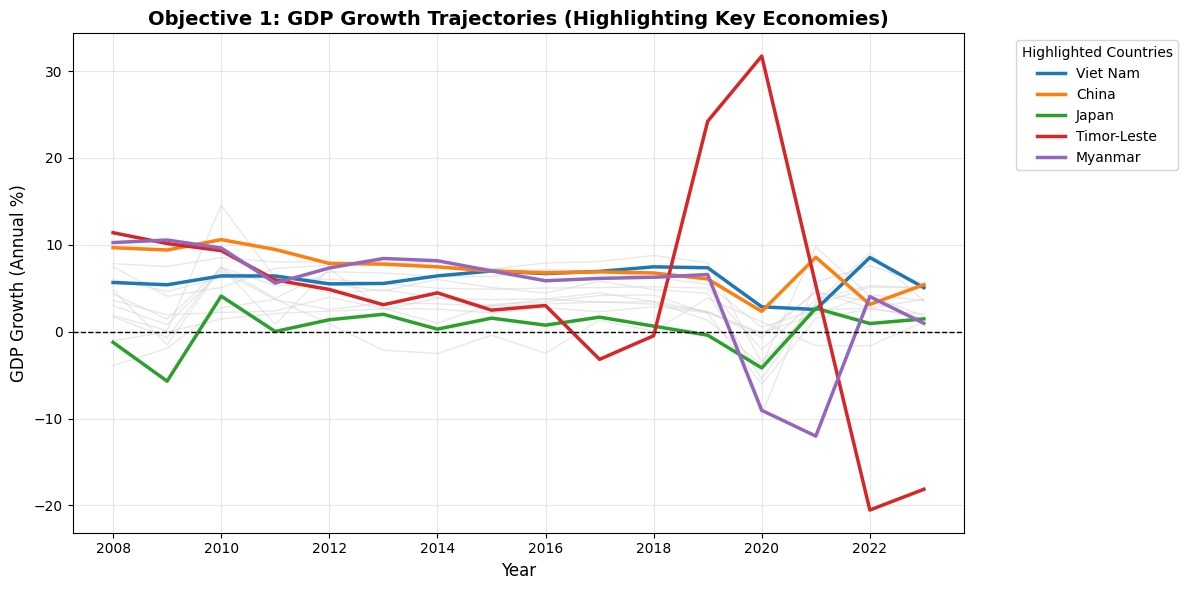

In [18]:
# Objective 1 Code
plt.figure(figsize=(12, 6))

# Define key countries to highlight
# VN, Timor Leste, Myanma, China, Japan
# highlight_countries = ['Viet Nam', 'China', 'Australia', 'Japan', 'Korea', 'New Zealand', 'Timor-Leste', 'Thailand', 'Singapore', 'Philippines', 'Myanmar', 'Malaysia', 'Lao PDR', 'Indonesia', 'Cambodia', 'Brunei Darussalam']
highlight_countries = ['Viet Nam', 'China', 'Japan', 'Timor-Leste', 'Myanmar']
palette = sns.color_palette("tab10", len(highlight_countries))

# Plot background countries (light gray)
for country in pivot_df['Country Name'].unique():
    if country not in highlight_countries:
        country_data = pivot_df[pivot_df['Country Name'] == country]
        sns.lineplot(data=country_data, x='Year', y='GDP growth (annual %)', color='lightgray', alpha=0.5, linewidth=1)

# Plot highlighted countries (colored and bold)
for idx, country in enumerate(highlight_countries):
    country_data = pivot_df[pivot_df['Country Name'] == country]
    sns.lineplot(data=country_data, x='Year', y='GDP growth (annual %)', color=palette[idx], label=country, linewidth=2.5)

# Add horizontal line at 0% for baseline reference
plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.title('Objective 1: GDP Growth Trajectories (Highlighting Key Economies)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('GDP Growth (Annual %)', fontsize=12)
plt.legend(title='Highlighted Countries', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

most economies grow ≤ 10% per year, though some experience GDP decline in some years.

Timor Leste is the most unstable, drop from 11% in 2008 to 0% in 2017, then has massive growth from 2018 but then dropping massively from 2020

VN growth is pretty stable, staying at around 5% per year

Japan's economy is stagnating, growth % either very small or even negative in some years

China growth rate is pretty stable, but has slowed down since 2008 (from 10% to 5%)

Myanmar growth was pretty stable until around 2019, then the economy shrink significantly in the next 2 years before finally growing again in 2021

**Analysis & Conclusion (Objective 1):**
*   **Global Shocks:** Two massive systemic shocks are visible across almost all countries: the 2008-2009 Global Financial Crisis (GFC) and the 2020 COVID-19 pandemic. In 2020, nearly all countries plummeted below the 0% growth line.
*   **Resilience:** Vietnam and China demonstrated remarkable resilience compared to developed nations like Japan and Australia. Vietnam was one of the very few countries to maintain positive GDP growth during the 2020 pandemic.

---

**Objective 2: Examine inflation-unemployment relationship (Phillips Curve perspective)**
*   **Chart Choice:** Scatter plot with a regression line. This is the optimal chart for determining the correlation between two numerical variables.

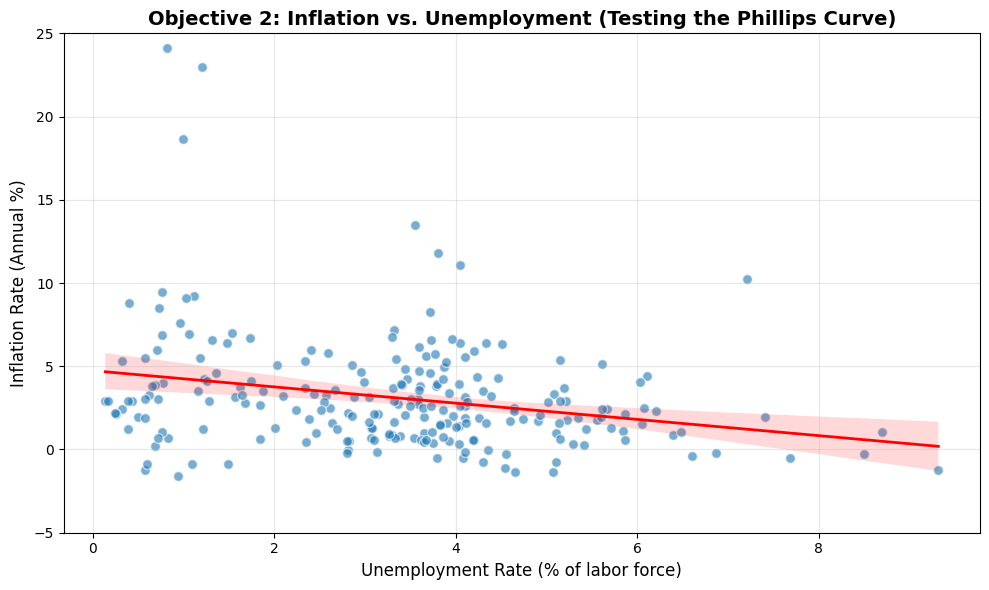

In [10]:
# Objective 2 Code
plt.figure(figsize=(10, 6))

# Scatter plot with regression line to show overall trend
sns.regplot(data=pivot_df, 
            x='Unemployment, total (% of total labor force) (national estimate)', 
            y='Inflation, consumer prices (annual %)', 
            scatter_kws={'alpha': 0.6, 'edgecolor': 'w', 's': 50},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Objective 2: Inflation vs. Unemployment (Testing the Phillips Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Unemployment Rate (% of labor force)', fontsize=12)
plt.ylabel('Inflation Rate (Annual %)', fontsize=12)

# Restrict axes slightly to avoid extreme outliers squishing the chart
plt.ylim(-5, 25) 
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 2):**
*   **Economic Theory vs. Reality:** The classical Phillips Curve dictates an inverse relationship (higher inflation correlates with lower unemployment). Our regression line shows a very weak or flat relationship.
*   **Conclusion:** In the modern Asia-Pacific context (especially post-2008), the Phillips curve relationship has broken down. Macroeconomic shocks, supply-chain disruptions, and varying monetary policies have led to periods where inflation and unemployment do not neatly trade off against each other.

---

**Objective 3: Compare GDP growth stability across countries**
*   **Chart Choice:** Boxplot. A boxplot excellently summarizes the distribution, central tendency (median), and volatility (IQR and outliers) of GDP growth for each country over the 16-year period.

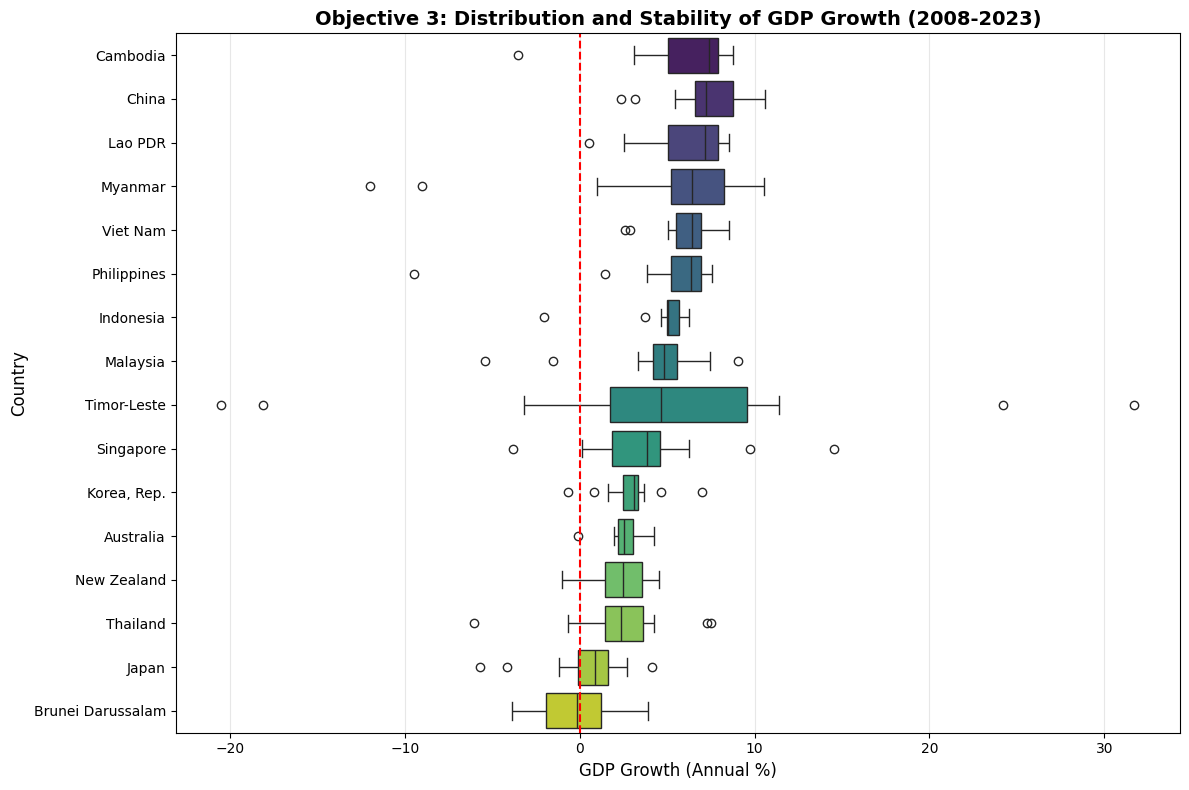

In [11]:
# Objective 3 Code
plt.figure(figsize=(12, 8))

# Calculate median GDP growth per country for sorting
median_gdp = pivot_df.groupby('Country Name')['GDP growth (annual %)'].median().sort_values(ascending=False)

# Boxplot sorted by median
sns.boxplot(data=pivot_df, 
            x='GDP growth (annual %)', 
            y='Country Name', 
            order=median_gdp.index,
            palette='viridis')

plt.axvline(0, color='red', linestyle='--', linewidth=1.5) # 0% growth reference line

plt.title('Objective 3: Distribution and Stability of GDP Growth (2008-2023)', fontsize=14, fontweight='bold')
plt.xlabel('GDP Growth (Annual %)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

reiterate what was said in objective 1

important to note the difference between objective 1 and 3. 1 is to tell the state of the economy in a specific year or from year to year, 3 is to tell the state of the economy in the entire period (grow or stagnate or decline)

**Analysis & Conclusion (Objective 3):**
*   **High vs. Low Volatility:** Developed economies like Australia and Japan have very narrow boxplots, indicating highly stable, albeit slower, economic growth. In contrast, emerging economies like Timor-Leste and Myanmar exhibit massive volatility (wide boxes and extreme outliers).
*   **Consistent Performers:** China and Vietnam rank at the top for median growth and maintain relatively compact distributions, signaling consistent, rapid economic expansion over the last 15 years.

### Theme 2: Energy Transition and Environmental Impact

**Objective 4: Assess the shift from fossil to renewable electricity**
*   **Chart Choice:** Stacked Area Chart (Regional Average). This chart type perfectly illustrates the composition of a whole (total electricity generation types) and how those proportions evolve over time.

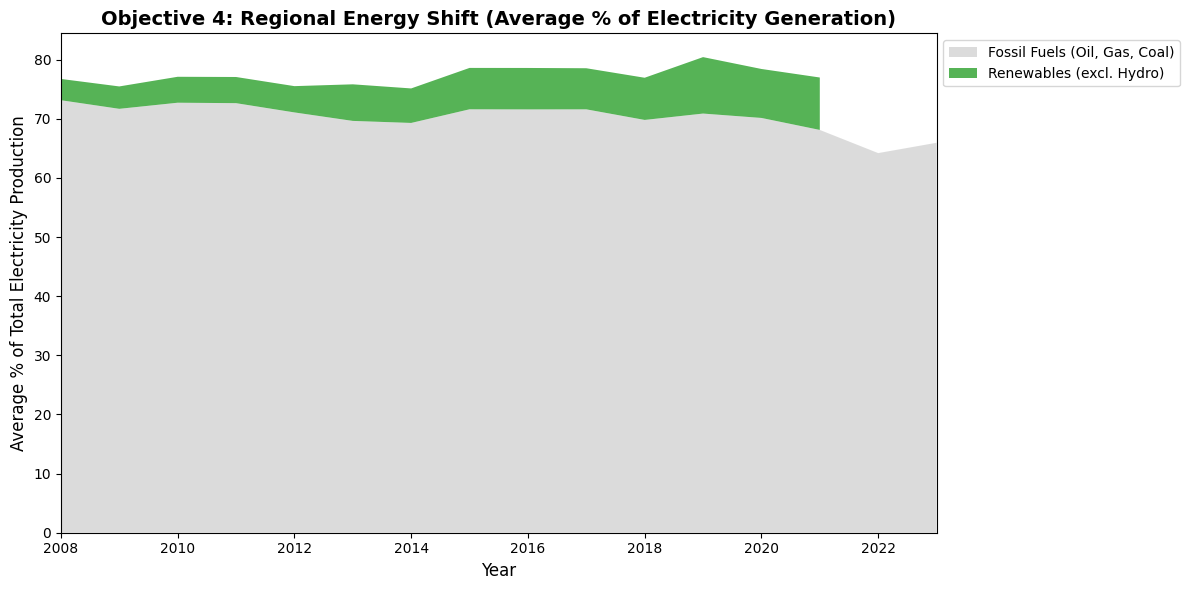

In [12]:
# Objective 4 Code
plt.figure(figsize=(12, 6))

# Calculate regional average per year
energy_trends = pivot_df.groupby('Year')[['Electricity production from oil, gas and coal sources (% of total)', 
                                          'Electricity production from renewable sources, excluding hydroelectric (% of total)']].mean()

plt.stackplot(energy_trends.index, 
              energy_trends['Electricity production from oil, gas and coal sources (% of total)'], 
              energy_trends['Electricity production from renewable sources, excluding hydroelectric (% of total)'],
              labels=['Fossil Fuels (Oil, Gas, Coal)', 'Renewables (excl. Hydro)'],
              colors=['#d3d3d3', '#2ca02c'], alpha=0.8)

plt.title('Objective 4: Regional Energy Shift (Average % of Electricity Generation)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average % of Total Electricity Production', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.margins(x=0)
plt.tight_layout()
plt.show()

energy from fossil fuel is still dominant, but there is a clear trend of using more renewable energy

**Analysis & Conclusion (Objective 4):**
*   **The Green Transition:** While fossil fuels still dominate the grid heavily across the region, the green band (renewables) shows a distinct, steady expansion, particularly accelerating after 2015. 
*   **Conclusion:** The region is actively undergoing an energy transition, though the pace highlights the persistent historical reliance on coal and gas.

---

**Objective 5: Analyze growth-emissions relationship**
*   **Chart Choice:** Scatter plot with logarithmic scaling. Because carbon emissions vary drastically (China is in the ten-thousands, while Brunei is single-digits), a log scale on the Y-axis is absolutely necessary to visualize all countries without data overlapping at the bottom.

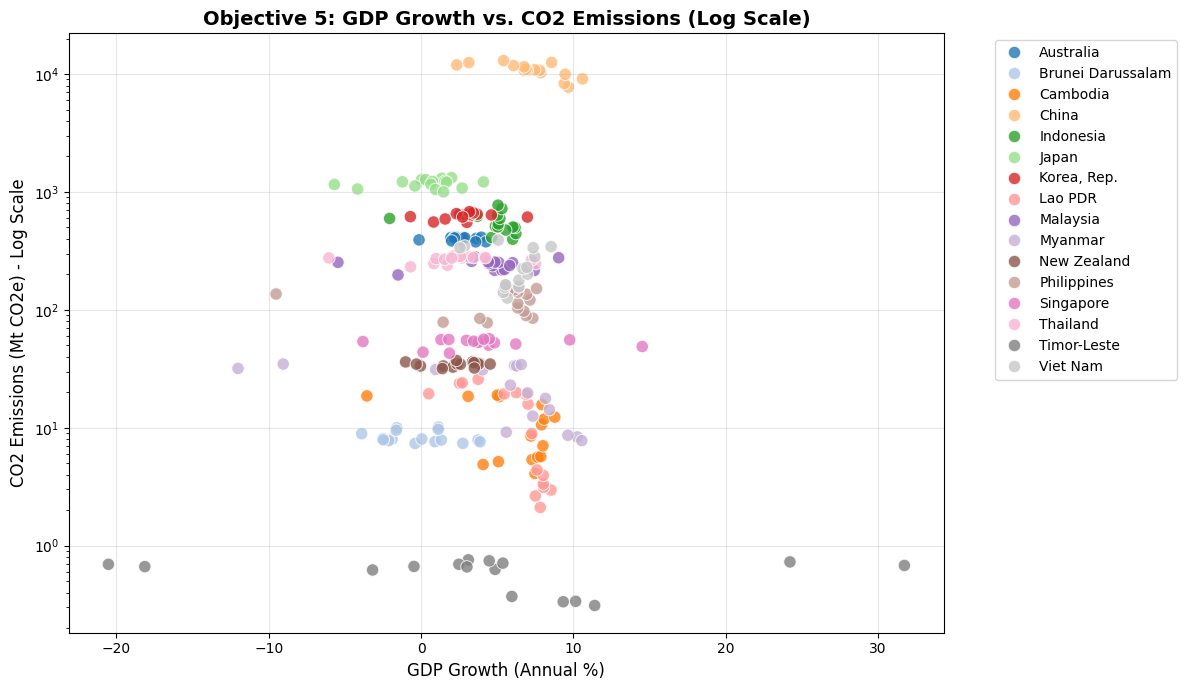

In [13]:
# Objective 5 Code
plt.figure(figsize=(12, 7))

sns.scatterplot(data=pivot_df, 
                x='GDP growth (annual %)', 
                y='Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)', 
                hue='Country Name', 
                palette='tab20', s=80, alpha=0.8)

# Logarithmic scale for CO2 emissions to handle extreme scale variance
plt.yscale('log')

plt.title('Objective 5: GDP Growth vs. CO2 Emissions (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('GDP Growth (Annual %)', fontsize=12)
plt.ylabel('CO2 Emissions (Mt CO2e) - Log Scale', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

china is the biggest emitter, while timor leste is the smallest.

grow rate tends to hover between 0-10%. and there's no clear relation between GDP growth and CO2 emissions (at gdp growth 0,2,4,8 we have emmissions from 10^0 to 10^3).

(This is not part of the chart analysis: population seems to be the bigger factor, but we dont visualise them right now)

**Analysis & Conclusion (Objective 5):**
*   **Scale of Emissions:** The log scale reveals distinct tiers of emitters. China and Japan occupy the highest emission tier, regardless of their GDP growth rate. 
*   **Decoupling:** Developed nations (e.g., Japan, Australia) hover around low GDP growth but high absolute emissions. Emerging nations show high growth but lower absolute emissions. There is no strict linear rule that higher annual growth immediately guarantees higher total emissions; industrial scale matters more.

---

**Objective 6: Track CO2 emissions trend (2008-2023)**
*   **Chart Choice:** Line chart with Log Scale. Similar to Objective 5, the immense gap between China and smaller ASEAN nations requires a log-scaled Y-axis to observe individual country trends over time.

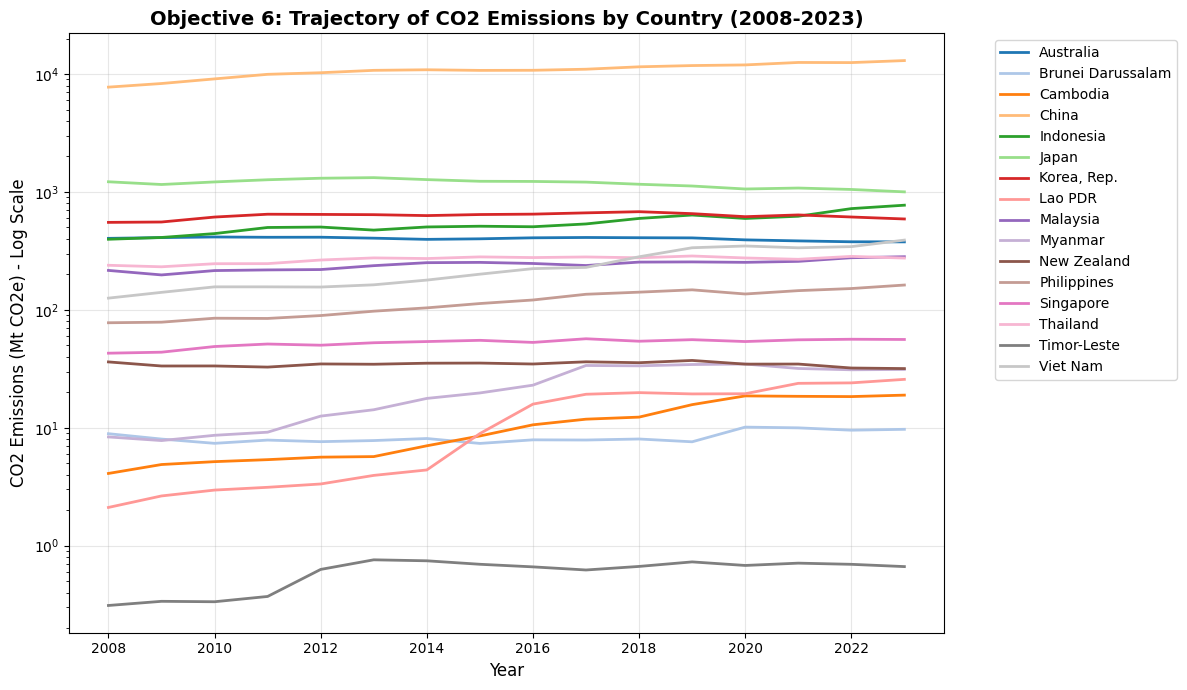

In [14]:
# Objective 6 Code
plt.figure(figsize=(12, 7))

sns.lineplot(data=pivot_df, 
             x='Year', 
             y='Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)', 
             hue='Country Name', 
             palette='tab20', linewidth=2)

# Logarithmic scale
plt.yscale('log')

plt.title('Objective 6: Trajectory of CO2 Emissions by Country (2008-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('CO2 Emissions (Mt CO2e) - Log Scale', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 6):**
*   **Emission Trajectories:** Most developed nations (Australia, Japan, New Zealand) show a slow but steady decline in emissions over the 15-year period.
*   **Developing Growth:** Conversely, rapidly industrializing nations (Vietnam, Indonesia, China) show steady upward slopes. This visualizes the core global climate dilemma: developing nations are increasing emissions to fuel economic catch-up, while developed nations are slowly decarbonizing.

### Theme 3: Human Capital and Educational Investment

**Objective 7: Evaluate government priority for education**
*   **Chart Choice:** Horizontal Bar Chart. A bar chart is the most effective way to rank categorical data (countries) based on a numeric value (average expenditure). Sorting the bars makes the comparison instantly readable.

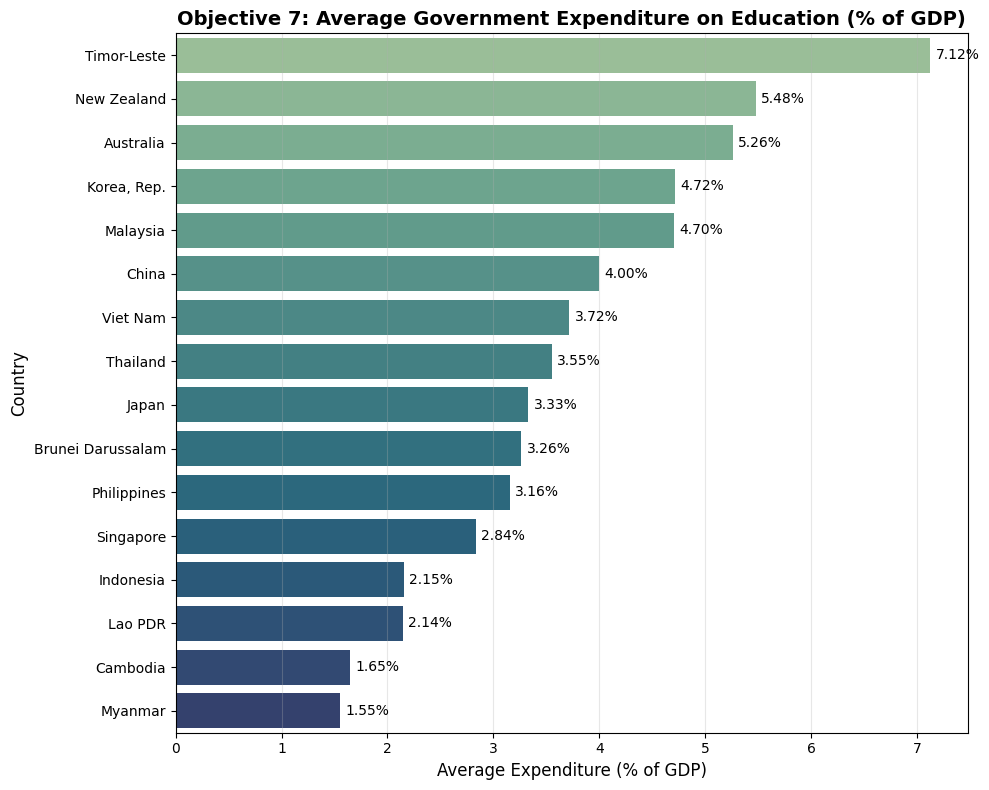

In [15]:
# Objective 7 Code
plt.figure(figsize=(10, 8))

# Calculate average education expenditure per country over the available years
edu_expenditure = pivot_df.groupby('Country Name')['Government expenditure on education, total (% of GDP)'].mean().sort_values(ascending=False)

# Drop countries with entirely NaN values for this metric to clean up the chart
edu_expenditure = edu_expenditure.dropna()

sns.barplot(x=edu_expenditure.values, y=edu_expenditure.index, palette='crest')

plt.title('Objective 7: Average Government Expenditure on Education (% of GDP)', fontsize=14, fontweight='bold')
plt.xlabel('Average Expenditure (% of GDP)', fontsize=12)
plt.ylabel('Country', fontsize=12)

# Add value labels to the end of the bars
for index, value in enumerate(edu_expenditure.values):
    plt.text(value + 0.05, index, f'{value:.2f}%', va='center', fontsize=10)

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Analysis & Conclusion (Objective 7):**
*   **Top Investors:** Timor-Leste and New Zealand lead the region in prioritizing education, allocating upwards of 5-7% of their total GDP. 
*   **Under-investors:** Surprisingly, some rapidly growing economies (like Cambodia and Indonesia) rank towards the bottom, dedicating less than 2% of their GDP to education. This lack of investment could pose a long-term risk to developing high-skilled labor forces.